# Unit Test 01: Unified Warp Benchmark

This notebook compares four warping paths on the same image pair and displacement field:

1. `warp_v0_spatialtrans.py` on GPU as the reference standard
2. Unified SciPy warp on CPU
3. Unified PyTorch `grid_sample` warp on CPU
4. Unified PyTorch `grid_sample` warp on GPU

## Dataset used in this notebook

- **Fixed image**: `3455` -> `LUMIRMRI_3455_0000.nii.gz`
- **Moving image**: `3454` -> `LUMIRMRI_3454_0000.nii.gz`
- **Displacement field**: `disp_3455_3454.nii.gz`

The working assumption in this notebook is that `disp_3455_3454` is defined on the **fixed lattice** and is used to sample the **moving image** into fixed-image space.

The benchmark settings requested here are:

- interpolation: linear / bilinear (`order=1`)
- padding: constant zero (`cval=0.0`)
- PyTorch: `align_corners=True`


In [1]:
import sys
import time
from pathlib import Path
from typing import Callable, Dict, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

if "/homebase" not in sys.path:
    sys.path.append("/homebase")

from code_sync.myMedIADIRLab.data_io.image.image_io import read_nifti
from code_sync.myMedIADIRLab.data_io.warp.warp_io import read_warp_nifti
from code_sync.myMedIADIRLab.data_io.warp.warp_v0_spatialtrans import SpatialTransformer
from code_sync.myMedIADIRLab.data_io.warp.warp_v1_unified import warp_image_unified


In [2]:
PROJECT_ROOT = Path("/homebase/code_sync/myMedIADIRLab/data_io")
DATA_DIR = PROJECT_ROOT / "unittest_warp" / "data_local"

FIXED_PATH = DATA_DIR / "LUMIRMRI_3455_0000.nii.gz"
MOVING_PATH = DATA_DIR / "LUMIRMRI_3454_0000.nii.gz"
DISP_PATH = DATA_DIR / "disp_3455_3454.nii.gz"

# fixed_image = read_nifti(FIXED_PATH)
# moving_image = read_nifti(MOVING_PATH)
# disp_raw = read_warp_nifti(DISP_PATH)

# fixed_np = np.asarray(fixed_image.array, dtype=np.float32)
# moving_np = np.asarray(moving_image.array, dtype=np.float32)
# disp_np = np.asarray(disp_raw, dtype=np.float32)


sys.path.insert(0, "/homebase/DL_projects/wavereg/code")
from utils_basics import numpy_overview, torch_overview
from utils_io import load_nifti_to_array

fixed_np = load_nifti_to_array(FIXED_PATH)
moving_np = load_nifti_to_array(MOVING_PATH)
disp_np = load_nifti_to_array(DISP_PATH)

print(f"Fixed image path   : {FIXED_PATH}")
print(f"Moving image path  : {MOVING_PATH}")
print(f"Displacement path  : {DISP_PATH}")
print()
print("Fixed image ID  : 3455")
print("Moving image ID : 3454")
print()
print("Fixed shape      :", fixed_np.shape)
print("Moving shape     :", moving_np.shape)
print("Disp raw shape   :", disp_np.shape)
print("Disp note        : raw file is loaded exactly as stored on disk")

assert fixed_np.shape == moving_np.shape, "Fixed and moving images must share the same spatial shape."
assert disp_np.shape in [(3,) + fixed_np.shape, fixed_np.shape + (3,)], "Expected 3D displacement in channel-first or channel-last format."


Fixed image path   : /homebase/code_sync/myMedIADIRLab/data_io/unittest_warp/data_local/LUMIRMRI_3455_0000.nii.gz
Moving image path  : /homebase/code_sync/myMedIADIRLab/data_io/unittest_warp/data_local/LUMIRMRI_3454_0000.nii.gz
Displacement path  : /homebase/code_sync/myMedIADIRLab/data_io/unittest_warp/data_local/disp_3455_3454.nii.gz

Fixed image ID  : 3455
Moving image ID : 3454

Fixed shape      : (160, 224, 192)
Moving shape     : (160, 224, 192)
Disp raw shape   : (3, 160, 224, 192)
Disp note        : raw file is loaded exactly as stored on disk


## Helper Functions

The helpers below do three things:

- convert numpy arrays to the tensor format expected by `SpatialTransformer`,
- time each method fairly, including CUDA synchronization when needed,
- report numeric differences relative to the GPU reference standard.


In [3]:
def disp_to_channel_first_3d(disp: np.ndarray, image_shape: Tuple[int, int, int]) -> np.ndarray:
    """Convert a 3D displacement field to channel-first `(3, X, Y, Z)` format."""
    if disp.shape == (3,) + image_shape:
        return disp.astype(np.float32, copy=False)
    if disp.shape == image_shape + (3,):
        return np.moveaxis(disp, -1, 0).astype(np.float32, copy=False)
    raise ValueError(f"Unsupported displacement shape {disp.shape} for image shape {image_shape}.")


def numpy_image_to_torch_volume(image: np.ndarray, device: torch.device) -> torch.Tensor:
    """Convert a 3D numpy image `(X, Y, Z)` to torch shape `(1, 1, X, Y, Z)`."""
    return torch.from_numpy(image.astype(np.float32, copy=False)).to(device=device).unsqueeze(0).unsqueeze(0)


def numpy_disp_to_torch_flow_channel_first(disp: np.ndarray, image_shape: Tuple[int, int, int], device: torch.device) -> torch.Tensor:
    """Convert a 3D numpy displacement field to torch shape `(1, 3, X, Y, Z)`."""
    disp_cf = disp_to_channel_first_3d(disp=disp, image_shape=image_shape)
    return torch.from_numpy(disp_cf).to(device=device).unsqueeze(0)


def synchronize_if_needed(device: Optional[torch.device]) -> None:
    """Synchronize CUDA timing if the device is CUDA; otherwise do nothing."""
    if device is not None and device.type == "cuda":
        torch.cuda.synchronize(device)


def time_numpy_callable(func: Callable[[], np.ndarray], repeat: int = 3, warmup: int = 1, device: Optional[torch.device] = None) -> Tuple[np.ndarray, float]:
    """Run a callable several times and return its final output and mean runtime in seconds."""
    output = None
    for _ in range(warmup):
        output = func()
        synchronize_if_needed(device)

    runtimes = []
    for _ in range(repeat):
        synchronize_if_needed(device)
        start_time = time.perf_counter()
        output = func()
        synchronize_if_needed(device)
        end_time = time.perf_counter()
        runtimes.append(end_time - start_time)

    assert output is not None
    return output, float(np.mean(runtimes))


def run_spatialtransformer_standard_gpu(moving: np.ndarray, disp: np.ndarray, gpu_index: int = 0) -> Tuple[np.ndarray, float]:
    """Run the legacy SpatialTransformer on GPU as the reference standard."""
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA is not available, so the GPU reference standard cannot run.")

    device = torch.device(f"cuda:{gpu_index}")
    src = numpy_image_to_torch_volume(moving, device=device)
    flow = numpy_disp_to_torch_flow_channel_first(disp=disp, image_shape=tuple(moving.shape), device=device)
    transformer = SpatialTransformer(size=tuple(moving.shape), persistent=False).to(device)
    transformer.eval()

    @torch.no_grad()
    def _run() -> np.ndarray:
        warped = transformer(src, flow, mode="bilinear", padding_mode="zeros", align_corners=True)
        return warped.squeeze(0).squeeze(0).detach().cpu().numpy()

    return time_numpy_callable(_run, repeat=3, warmup=1, device=device)


def run_unified_scipy(moving: np.ndarray, disp: np.ndarray) -> Tuple[np.ndarray, float]:
    """Run the unified SciPy implementation on CPU."""
    def _run() -> np.ndarray:
        return warp_image_unified(
            image=moving,
            disp=disp,
            backend="scipy",
            order=1,
            padding_mode="constant",
            cval=0.0,
            debug=False,
        )

    return time_numpy_callable(_run, repeat=3, warmup=1, device=None)


def run_unified_torch_cpu(moving: np.ndarray, disp: np.ndarray) -> Tuple[np.ndarray, float]:
    """Run the unified torch implementation on CPU."""
    def _run() -> np.ndarray:
        return warp_image_unified(
            image=moving,
            disp=disp,
            backend="torch",
            order=1,
            padding_mode="constant",
            cval=0.0,
            device="cpu",
            debug=False,
        )

    return time_numpy_callable(_run, repeat=3, warmup=1, device=None)


def run_unified_torch_gpu(moving: np.ndarray, disp: np.ndarray, gpu_index: int = 0) -> Tuple[np.ndarray, float]:
    """Run the unified torch implementation on GPU."""
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA is not available, so the unified GPU warp cannot run.")

    device = torch.device(f"cuda:{gpu_index}")

    def _run() -> np.ndarray:
        return warp_image_unified(
            image=moving,
            disp=disp,
            backend="torch",
            order=1,
            padding_mode="constant",
            cval=0.0,
            device=gpu_index,
            debug=False,
        )

    return time_numpy_callable(_run, repeat=3, warmup=1, device=device)


def compare_to_reference(reference: Optional[np.ndarray], candidate: np.ndarray) -> Dict[str, float]:
    """Compute simple numeric differences relative to the reference result."""
    if reference is None:
        return {
            "mae_vs_standard": np.nan,
            "rmse_vs_standard": np.nan,
            "max_abs_vs_standard": np.nan,
        }

    diff = candidate.astype(np.float32) - reference.astype(np.float32)
    return {
        "mae_vs_standard": float(np.mean(np.abs(diff))),
        "rmse_vs_standard": float(np.sqrt(np.mean(diff ** 2))),
        "max_abs_vs_standard": float(np.max(np.abs(diff))),
    }


In [4]:
GPU_INDEX = 0
results: Dict[str, np.ndarray] = {}
timings: Dict[str, float] = {}

standard_result: Optional[np.ndarray] = None

try:
    standard_result, standard_time = run_spatialtransformer_standard_gpu(moving=moving_np, disp=disp_np, gpu_index=GPU_INDEX)
    results["standard_gpu_v0"] = standard_result
    timings["standard_gpu_v0"] = standard_time
    print(f"standard_gpu_v0 finished in {standard_time:.6f} s")
except Exception as exc:
    print(f"standard_gpu_v0 skipped: {exc}")

scipy_result, scipy_time = run_unified_scipy(moving=moving_np, disp=disp_np)
results["unified_scipy_cpu"] = scipy_result
timings["unified_scipy_cpu"] = scipy_time
print(f"unified_scipy_cpu finished in {scipy_time:.6f} s")

torch_cpu_result, torch_cpu_time = run_unified_torch_cpu(moving=moving_np, disp=disp_np)
results["unified_torch_cpu"] = torch_cpu_result
timings["unified_torch_cpu"] = torch_cpu_time
print(f"unified_torch_cpu finished in {torch_cpu_time:.6f} s")

try:
    torch_gpu_result, torch_gpu_time = run_unified_torch_gpu(moving=moving_np, disp=disp_np, gpu_index=GPU_INDEX)
    results["unified_torch_gpu"] = torch_gpu_result
    timings["unified_torch_gpu"] = torch_gpu_time
    print(f"unified_torch_gpu finished in {torch_gpu_time:.6f} s")
except Exception as exc:
    print(f"unified_torch_gpu skipped: {exc}")


standard_gpu_v0 finished in 0.015302 s
unified_scipy_cpu finished in 0.597091 s
unified_torch_cpu finished in 0.478753 s
unified_torch_gpu finished in 0.035183 s


In [5]:
summary_rows = []
for method_name, warped_np in results.items():
    row = {
        "method": method_name,
        "time_seconds": timings[method_name],
        "output_shape": tuple(warped_np.shape),
        "output_dtype": str(warped_np.dtype),
    }
    row.update(compare_to_reference(reference=standard_result, candidate=warped_np))
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(by="time_seconds", ascending=True).reset_index(drop=True)
summary_df


,method,time_seconds,output_shape,output_dtype,mae_vs_standard,rmse_vs_standard,max_abs_vs_standard
0,standard_gpu_v0,0.015302,"(160, 224, 192)",float32,0.000000,0.000000,0.000000
1,unified_torch_gpu,0.035183,"(160, 224, 192)",float32,0.000000,0.000000,0.000000
2,unified_torch_cpu,0.478753,"(160, 224, 192)",float32,0.000016,0.000059,0.002022
3,unified_scipy_cpu,0.597091,"(160, 224, 192)",float32,0.000016,0.000056,0.001640


## Visual Check

The plots below show the central axial slice of:

- fixed image,
- moving image,
- each warped image,
- absolute difference to the GPU reference standard when available.


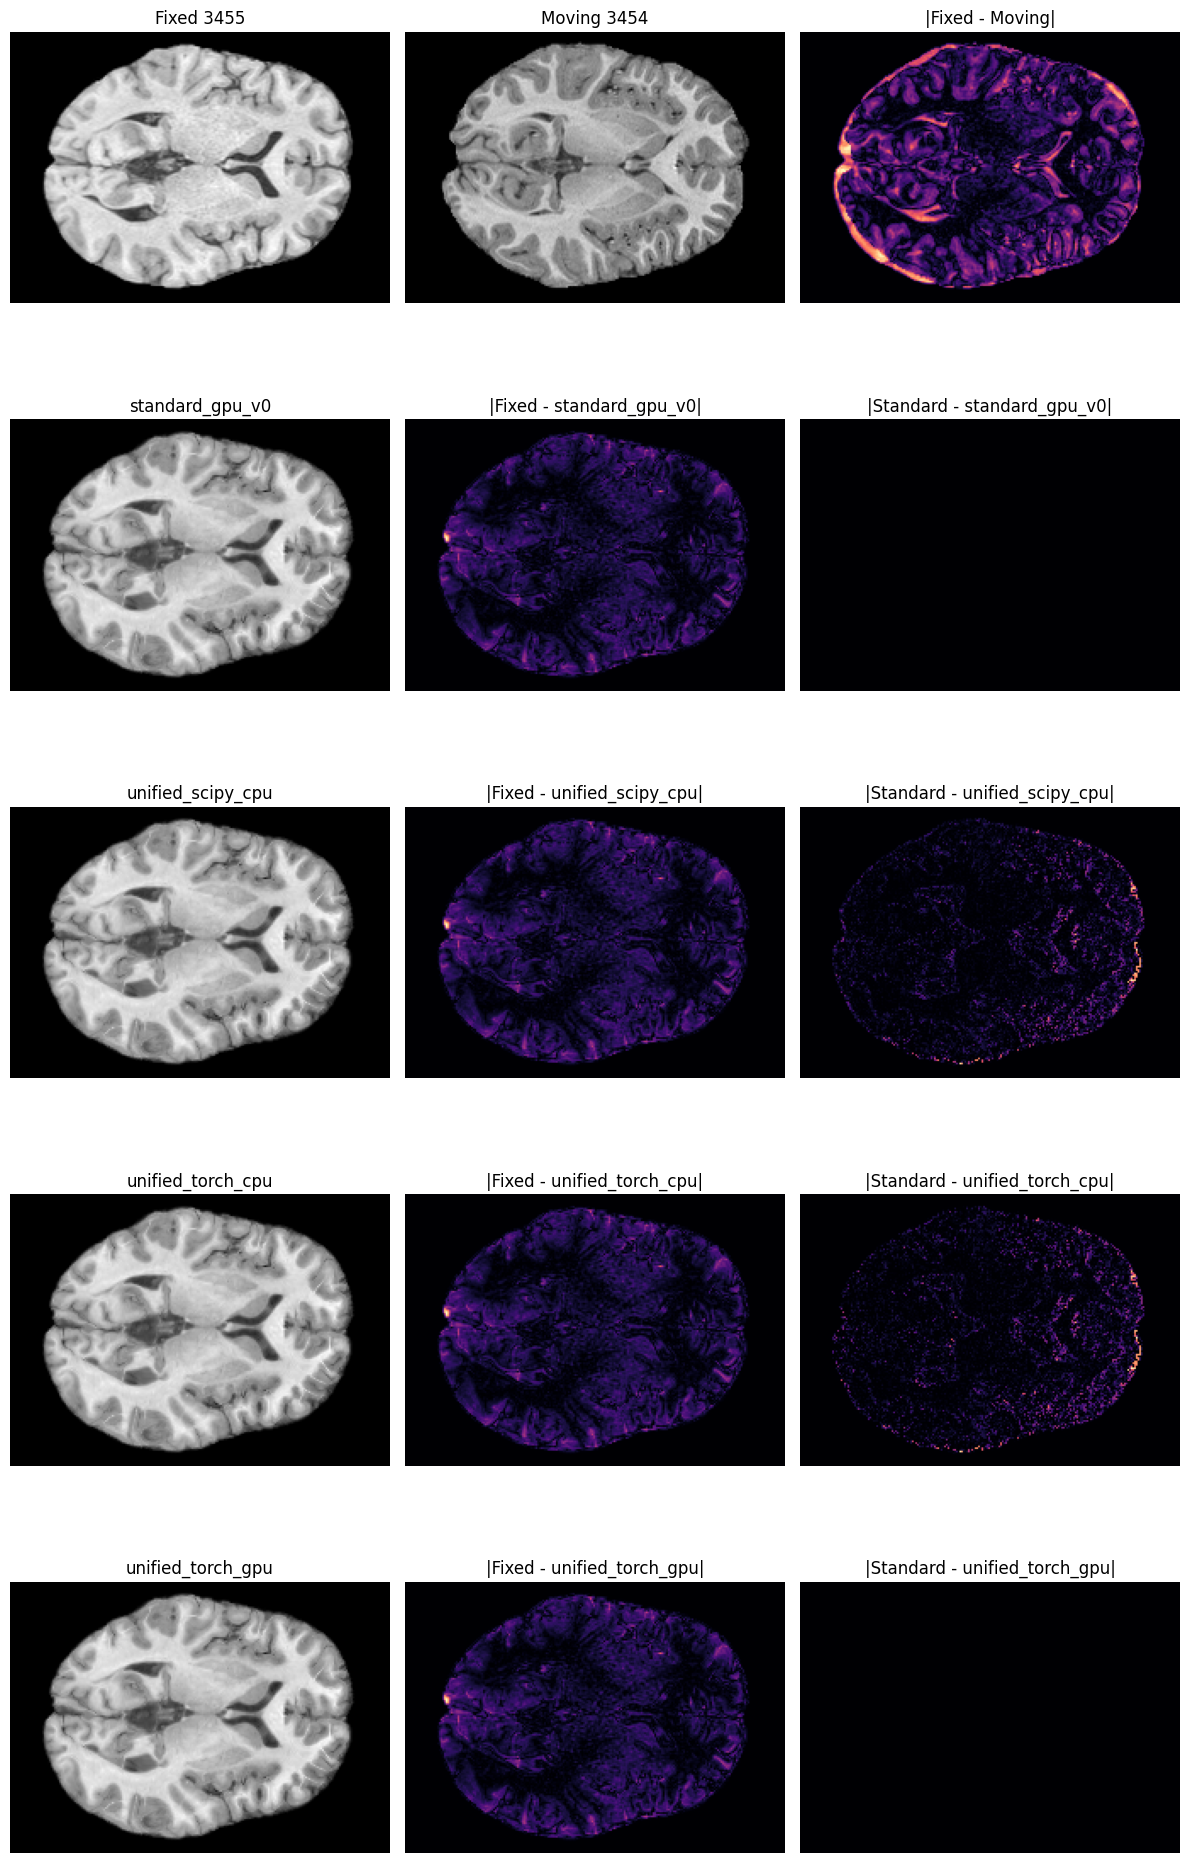

In [6]:
slice_index = fixed_np.shape[2] // 2
method_names = list(results.keys())
nrows = len(method_names) + 1
fig, axes = plt.subplots(nrows=nrows, ncols=3, figsize=(12, 4 * nrows))

axes[0, 0].imshow(fixed_np[:, :, slice_index], cmap="gray")
axes[0, 0].set_title("Fixed 3455")
axes[0, 1].imshow(moving_np[:, :, slice_index], cmap="gray")
axes[0, 1].set_title("Moving 3454")
axes[0, 2].imshow(np.abs(fixed_np[:, :, slice_index] - moving_np[:, :, slice_index]), cmap="magma")
axes[0, 2].set_title("|Fixed - Moving|")

for row_index, method_name in enumerate(method_names, start=1):
    warped_np = results[method_name]
    axes[row_index, 0].imshow(warped_np[:, :, slice_index], cmap="gray")
    axes[row_index, 0].set_title(method_name)
    axes[row_index, 1].imshow(np.abs(fixed_np[:, :, slice_index] - warped_np[:, :, slice_index]), cmap="magma")
    axes[row_index, 1].set_title(f"|Fixed - {method_name}|")

    if standard_result is not None:
        diff_vs_standard = np.abs(standard_result[:, :, slice_index] - warped_np[:, :, slice_index])
        axes[row_index, 2].imshow(diff_vs_standard, cmap="magma")
        axes[row_index, 2].set_title(f"|Standard - {method_name}|")
    else:
        axes[row_index, 2].axis("off")
        axes[row_index, 2].set_title("Standard unavailable")

for ax in axes.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()


In [7]:
print("Quick unified debug run:")
debug_result = warp_image_unified(
    image=moving_np,
    disp=disp_np,
    backend="torch",
    order=1,
    padding_mode="constant",
    cval=0.0,
    device="cpu",
    debug=True,
)
print("Debug output shape:", debug_result.shape)


Quick unified debug run:
[warp_image_unified] backend: torch
[warp_image_unified] spatial_ndim: 3
[warp_image_unified] image_shape: (160, 224, 192)
[warp_image_unified] image_dtype: float64
[warp_image_unified] disp_original_shape: (3, 160, 224, 192)
[warp_image_unified] disp_original_dtype: float64
[warp_image_unified] disp_detected_layout: channel_first
[warp_image_unified] disp_channel_last_shape: (160, 224, 192, 3)
[warp_image_unified] compute_dtype: float32
[warp_image_unified] order: 1
[warp_image_unified] padding_mode: constant
[warp_image_unified] cval: 0.0
[warp_image_unified] torch_device: cpu
[warp_image_unified] torch_mode: bilinear
[warp_image_unified] torch_padding_mode: zeros
[warp_image_unified] align_corners: True
Debug output shape: (160, 224, 192)
